Accuracy: 0.9736842105263158

Confusion Matrix:
 [[40  3]
 [ 0 71]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



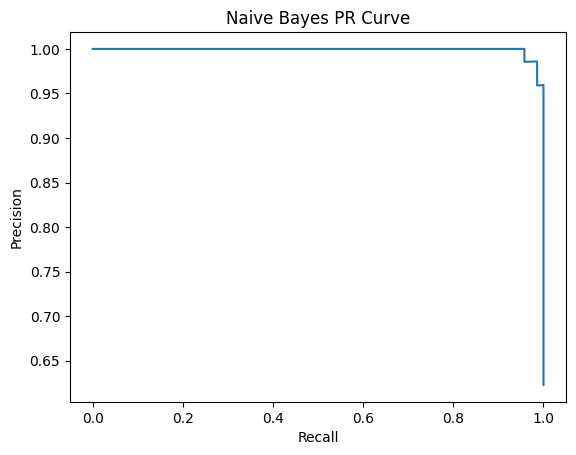

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, auc

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = GaussianNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Naive Bayes PR Curve")
plt.show()

Accuracy: 0.9473684210526315

Confusion Matrix:
 [[40  3]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



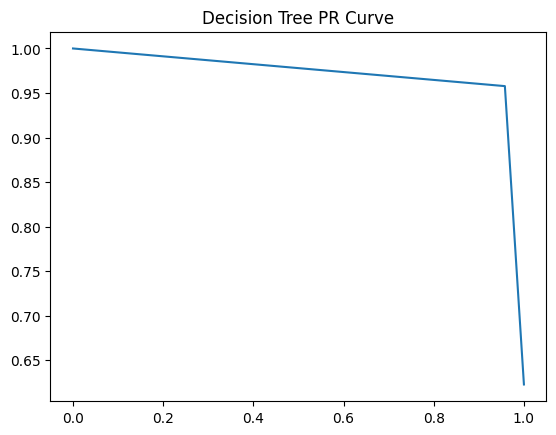

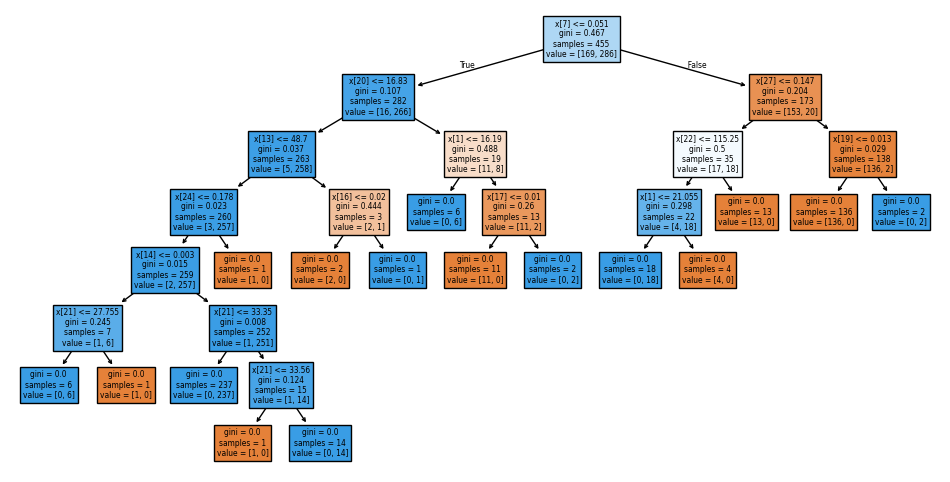

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.title("Decision Tree PR Curve")
plt.show()

# Tree Visualization
plt.figure(figsize=(12,6))
plot_tree(dt_model, filled=True)
plt.show()


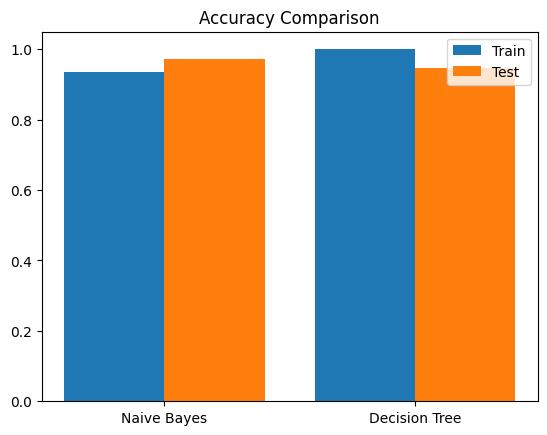

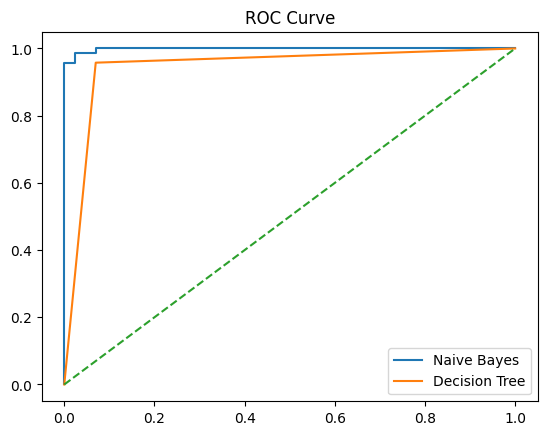

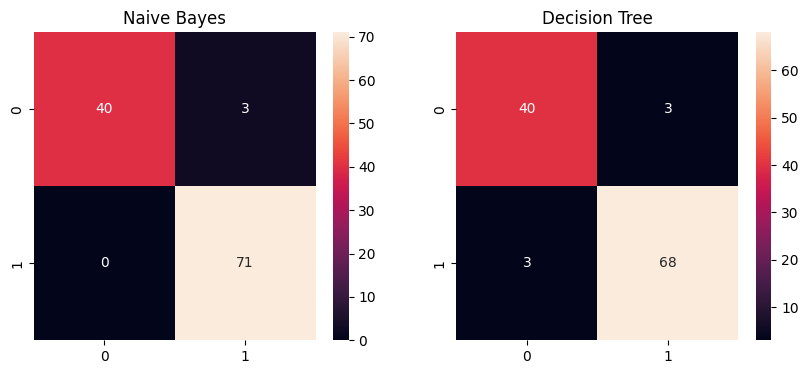

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns

# Train both models
nb = GaussianNB()
dt = DecisionTreeClassifier(random_state=42)

nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Accuracy
nb_train = accuracy_score(y_train, nb.predict(X_train))
nb_test = accuracy_score(y_test, nb.predict(X_test))

dt_train = accuracy_score(y_train, dt.predict(X_train))
dt_test = accuracy_score(y_test, dt.predict(X_test))

# Bar chart
models = ['Naive Bayes', 'Decision Tree']
train_acc = [nb_train, dt_train]
test_acc = [nb_test, dt_test]

x = np.arange(len(models))
plt.bar(x - 0.2, train_acc, 0.4, label='Train')
plt.bar(x + 0.2, test_acc, 0.4, label='Test')
plt.xticks(x, models)
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

# ROC Curve
nb_prob = nb.predict_proba(X_test)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]

nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

plt.plot(nb_fpr, nb_tpr, label="Naive Bayes")
plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, nb.predict(X_test)), annot=True, fmt='d')
plt.title("Naive Bayes")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, dt.predict(X_test)), annot=True, fmt='d')
plt.title("Decision Tree")

plt.show()